In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import imageio

## 1. Moving array setup

Text(0.5, 1.0, '500Hz wavefront angle: 60deg')

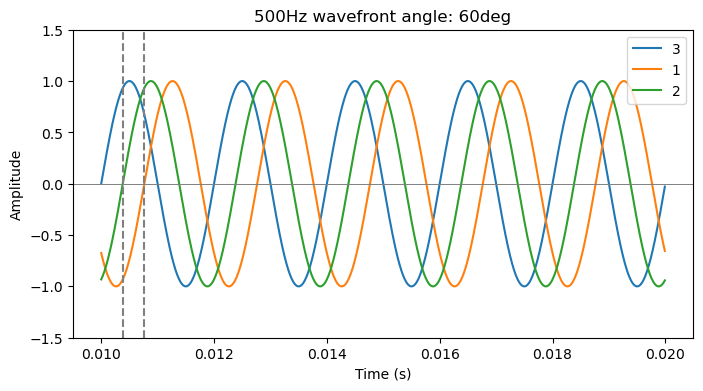

In [4]:
t = 1
fsample = 110000
samples = np.linspace(0, t, fsample)
freq = 500
sig3 = np.sin(2*np.pi*freq*samples)
tpi = int((fsample/(t*freq))*5)
tpf = int((fsample/(t*freq))*10)
theta = 60
d = 0.3
c0 = 340

fig, ax = plt.subplots(figsize = (8, 4))
p2 = 0.5*d*np.sin(theta*np.pi/180)/c0
p1 = d*np.sin(theta*np.pi/180)/c0
sig2 = np.sin(2*np.pi*freq*samples - 2*np.pi*freq*p2)
sig1 = np.sin(2*np.pi*freq*samples - 2*np.pi*freq*p1)
ax.plot(samples[tpi:tpf], sig3[tpi:tpf], label = '3')
ax.plot(samples[tpi:tpf], sig1[tpi:tpf], label = '1')
ax.plot(samples[tpi:tpf], sig2[tpi:tpf], label = '2')
ax.legend()
ax.set_ylabel("Amplitude")
ax.set_xlabel("Time (s)")
ax.set_ylim([-1.5, 1.5])
ax.axvline(5/freq + p1, color = 'grey', ls = '--')
ax.axvline(5/freq + p2, color = 'grey', ls = '--')
ax.axhline(0, color = 'grey', lw = 0.7)
ax.set_title(f'{freq}Hz wavefront angle: {theta}deg')
# fig.savefig('angled_wf.png')

Text(0.5, 1.0, '500Hz wavefront angle: 90deg')

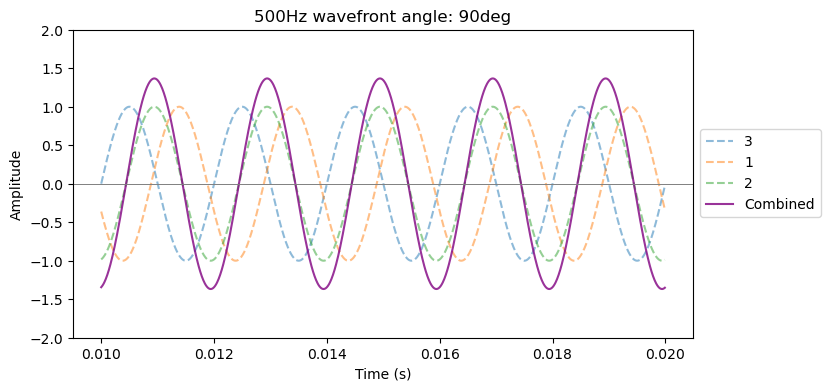

In [6]:
theta = 90
fig, ax = plt.subplots(figsize = (8, 4))
sig3 = np.sin(2*np.pi*freq*samples)
p2 = 0.5*d*np.sin(theta*np.pi/180)/c0
p1 = d*np.sin(theta*np.pi/180)/c0
sig2 = np.sin(2*np.pi*freq*samples - 2*np.pi*freq*p2)
sig1 = np.sin(2*np.pi*freq*samples - 2*np.pi*freq*p1)
sig = sig1 + sig2 + sig3
ax.plot(samples[tpi:tpf], sig3[tpi:tpf], ls = '--', label = '3', alpha = 0.5)
ax.plot(samples[tpi:tpf], sig1[tpi:tpf], ls = '--', label = '1', alpha = 0.5)
ax.plot(samples[tpi:tpf], sig2[tpi:tpf], ls = '--', label = '2', alpha = 0.5)
ax.plot(samples[tpi:tpf], sig[tpi:tpf], color = 'purple', label = 'Combined', alpha = 0.8)
ax.legend(bbox_to_anchor = (1, 0.7))
ax.set_ylabel("Amplitude")
ax.set_xlabel("Time (s)")
ax.set_ylim([-2, 2])
# ax.axvline(5/freq + p1, color = 'grey', ls = '--')
# ax.axvline(5/freq + p2, color = 'grey', ls = '--')
ax.axhline(0, color = 'grey', lw = 0.7)
ax.set_title(f'{freq}Hz wavefront angle: {theta}deg')
# fig.savefig('angled_wf2.png')

In [ ]:
tmax = 360
frames = []
tpf = tpi
tpi = 0
for theta in np.linspace(0, tmax, tmax+1):
    fig, ax = plt.subplots(figsize = (12, 5))
    p2 = 0.5*d*np.sin(theta*np.pi/180)/c0
    p1 = d*np.sin(theta*np.pi/180)/c0
    sig2 = np.sin(2*np.pi*freq*samples - 2*np.pi*freq*p2)
    sig1 = np.sin(2*np.pi*freq*samples - 2*np.pi*freq*p1)
    sig = sig1 + sig2 + sig3
    ax.plot(samples[tpi:tpf], sig3[tpi:tpf], ls = '--', label = '3', alpha = 0.5)
    ax.plot(samples[tpi:tpf], sig1[tpi:tpf], ls = '--', label = '1', alpha = 0.5)
    ax.plot(samples[tpi:tpf], sig2[tpi:tpf], ls = '--', label = '2', alpha = 0.5)
    ax.plot(samples[tpi:tpf], sig[tpi:tpf], color = 'purple', label = 'Combined', alpha = 0.8)
    ax.legend(bbox_to_anchor = (1, 0.7))
    ax.set_ylabel("Amplitude")
    ax.set_xlabel("Time (s)")
    ax.set_ylim([-3, 3])
    # ax.axvline(5/freq + p1, color = 'grey', ls = '--')
    # ax.axvline(5/freq + p2, color = 'grey', ls = '--')
    ax.axhline(0, color = 'grey', lw = 0.7)
    ax.set_title(f'{freq}Hz wavefront angle: {theta}deg')
    fig.canvas.draw()
    rgba_buffer = fig.canvas.buffer_rgba()
    image = np.array(rgba_buffer)
    image_rgb = image[:, :, :3]
    frames.append(image_rgb)
    plt.close(fig)
# imageio.mimsave('array_wf_thetas.gif', frames, fps = 10, loop=0)

In [49]:
tmax = 360
vals = []
tpf = tpi
tpi = 0
freq = 500
for theta in np.linspace(0, tmax, tmax+1):
    p2 = 0.5*d*np.sin(theta*np.pi/180)/c0
    p1 = d*np.sin(theta*np.pi/180)/c0
    sig2 = np.sin(2*np.pi*freq*samples - 2*np.pi*freq*p2)
    sig1 = np.sin(2*np.pi*freq*samples - 2*np.pi*freq*p1)
    sig = sig1 + sig2 + sig3
    vals.append(sig.max())

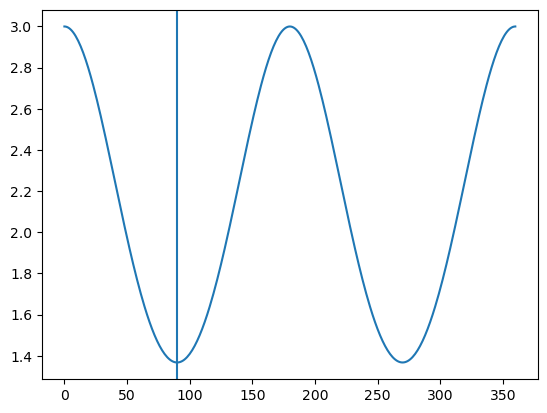

In [57]:
plt.plot(np.linspace(0, tmax, tmax+1), vals)
plt.axvline(90)

## 2. Stationary array setup

Text(0.5, 1.0, 'Recorded response of array')

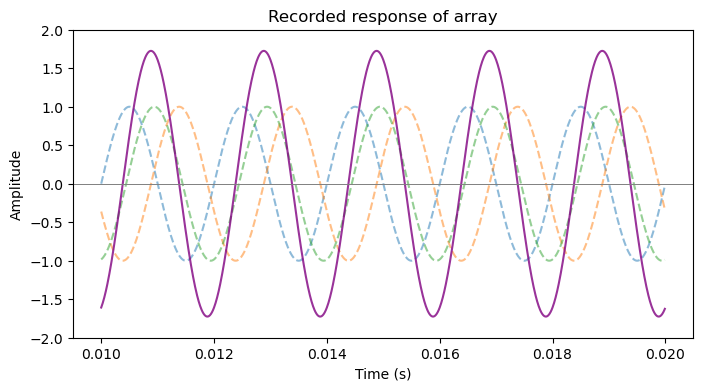

In [8]:
def shift_signal(signal, t):
    sampling_rate = signal.shape[0]
    shift = int(t*sampling_rate)
    shifted_sig = np.roll(signal, shift)
    if shift > 0:
        shifted_sig[:shift] = 0
    elif shift < 0:
        shifted_sig[shift:] = 0
    return shifted_sig
    
# Unknown to the array
t = 1
fsample = 110000
samples = np.linspace(0, t, fsample)
freq = 500
sig3 = np.sin(2*np.pi*freq*samples)
tpi = int((fsample/(t*freq))*5)
tpf = int((fsample/(t*freq))*10)
theta = 60
d = 0.3
c0 = 340

# tpf = tpi
# tpi = 0
fig, ax = plt.subplots(figsize = (8, 4))
p2a = 0.5*d*np.sin(theta*np.pi/180)/c0
p1a = d*np.sin(theta*np.pi/180)/c0
sig2a = shift_signal(sig3, p2a)
sig1a = shift_signal(sig3, p1a)
siga = sig1a + sig2a + sig3
ax.plot(samples[tpi:tpf], sig3[tpi:tpf], ls = '--', label = '3', alpha = 0.5)
ax.plot(samples[tpi:tpf], sig1[tpi:tpf], ls = '--', label = '1', alpha = 0.5)
ax.plot(samples[tpi:tpf], sig2[tpi:tpf], ls = '--', label = '2', alpha = 0.5)
ax.plot(samples[tpi:tpf], siga[tpi:tpf], color = 'purple', alpha = 0.8)
ax.set_ylabel("Amplitude")
ax.set_xlabel("Time (s)")
ax.set_ylim([-2, 2])
ax.axhline(0, color = 'grey', lw = 0.7)
ax.set_title(f'Recorded response of array')
# fig.savefig('array_response.png')

In [275]:
ang = 60
lim = 2.5
tmax = 360
frames = []
for ang0 in np.linspace(0, tmax, tmax+1):
    r, c = 13, 10
    sq = 6
    fig = plt.figure(figsize=(r, c))
    ax1 = plt.subplot2grid((c, r), (0, int(0.5*(r - sq))), rowspan=sq, colspan=sq)
    ax2 = plt.subplot2grid((c, r), (6, 0), rowspan=4, colspan=r)
    ax1.scatter([-1, 0, 1], [0, 0, 0], color = 'black')
    ax1.plot([1, 1-lim*np.cos(ang*np.pi/180)], [0, lim*np.sin(ang*np.pi/180)], color = 'black', ls = '--', alpha = 0.4, label = f'Actual {ang}°')
    ax1.plot([1, 1-lim*np.cos(ang0*np.pi/180)], [0, lim*np.sin(ang0*np.pi/180)], alpha = 0.8, ls = '--')
    ax1.set_xlim([-3, 3])
    ax1.set_ylim([-3, 3])
    ax1.legend(bbox_to_anchor = (0, 0.6))
    ax1.set_title(f'Angle = {ang0}°')
    ax1.set_xticks([])
    ax1.set_yticks([])
    for spine in ax1.spines.values():
        spine.set_visible(False)
    
    theta0 = ang0
    p2 = 0.5*d*np.sin(theta0*np.pi/180)/c0
    p1 = d*np.sin(theta0*np.pi/180)/c0
    sig2 = shift_signal(sig2a, -p2)
    sig1 = shift_signal(sig1a, -p1)
    sig = sig1 + sig2 + sig3
    ax2.plot(samples[tpi:tpf], sig3[tpi:tpf], ls = '--', label = '3', alpha = 0.5)
    ax2.plot(samples[tpi:tpf], sig1[tpi:tpf], ls = '--', label = '1', alpha = 0.5)
    ax2.plot(samples[tpi:tpf], sig2[tpi:tpf], ls = '--', label = '2', alpha = 0.5)
    ax2.plot(samples[tpi:tpf], sig[tpi:tpf], color = 'purple', label = 'Array', alpha = 0.8)
    ax2.legend(bbox_to_anchor = (1, 0.7))
    ax2.set_ylabel("Amplitude")
    ax2.set_xlabel("Time (s)")
    ax2.set_ylim([-3, 3])
    # ax.axvline(5/freq + p1, color = 'grey', ls = '--')
    # ax.axvline(5/freq + p2, color = 'grey', ls = '--')
    ax2.axhline(0, color = 'grey', lw = 0.7)
    ax2.set_title(f'{freq}Hz Signal')
    
    fig.canvas.draw()
    rgba_buffer = fig.canvas.buffer_rgba()
    image = np.array(rgba_buffer)
    image_rgb = image[:, :, :3]
    frames.append(image_rgb)
    plt.close(fig)
imageio.mimsave('steering_.gif', frames, fps = 20, loop=0)

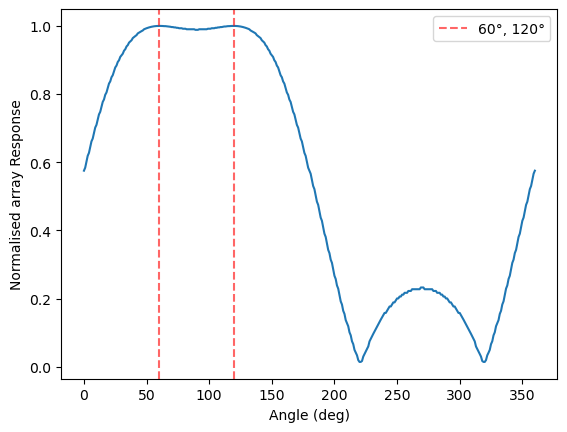

In [287]:
vals = []
for theta0 in np.linspace(0, tmax, tmax+1):
    p2 = 0.5*d*np.sin(theta0*np.pi/180)/c0
    p1 = d*np.sin(theta0*np.pi/180)/c0
    sig2 = shift_signal(sig2a, -p2)
    sig1 = shift_signal(sig1a, -p1)
    sig = sig1 + sig2 + sig3
    q1 = np.sqrt(np.mean(sig1**2))
    q2 = np.sqrt(np.mean(sig2**2))
    q3 = np.sqrt(np.mean(sig3**2))
    qs = np.sqrt(np.mean(sig**2))
    q = qs/(q1 + q2 + q3)
    vals.append(q)
plt.plot(vals)
plt.xlabel('Angle (deg)')
plt.ylabel('Normalised array Response')
plt.axvline(60, color = 'r', ls = '--', alpha = 0.6, label = '60°, 120°')
plt.axvline(120, color = 'r', ls = '--', alpha = 0.6)
plt.legend()
plt.savefig('Array Response vs angles.png')

## 3. Composite wave

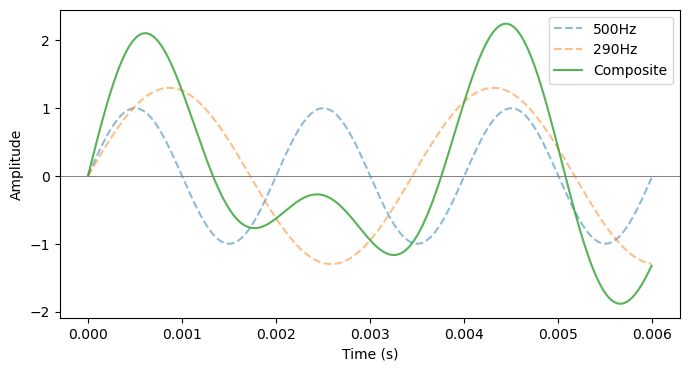

In [60]:
#sig3
t = 1
fsample = 110000
samples = np.linspace(0, t, fsample)
freq1 = 500
freq2 = 290
sig3_1 = np.sin(2*np.pi*freq1*samples)
sig3_2 = 1.3*np.sin(2*np.pi*freq2*samples)
tp = 3*int(fsample / max(freq1, freq2))

sig3 = sig3_1 + sig3_2

fig, ax = plt.subplots(figsize = (8, 4))
ax.plot(samples[:tp], sig3_1[:tp], ls = '--', label = f'{freq1}Hz', alpha = 0.5)
ax.plot(samples[:tp], sig3_2[:tp], ls = '--', label = f'{freq2}Hz', alpha = 0.5)
ax.plot(samples[:tp], sig3[:tp], label = f'Composite', alpha = 0.8)
ax.legend()
ax.set_ylabel("Amplitude")
ax.set_xlabel("Time (s)")
ax.axhline(0, color = 'grey', lw = 0.7)
# ax.set_title(f'{freq}Hz wavefront angle: {theta}deg')
# fig.savefig('Composite_wave.png')

Text(0.5, 1.0, 'Composite wavefront angle: 55deg')

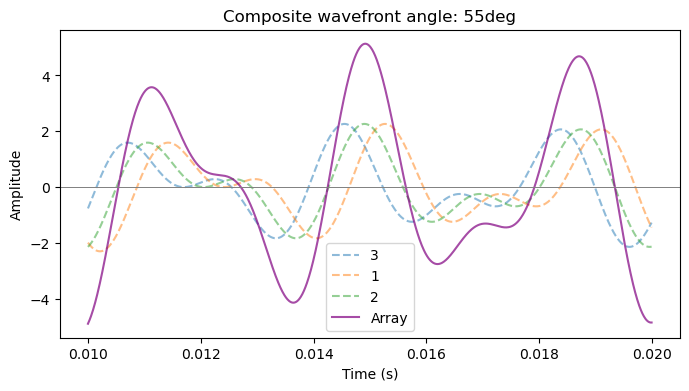

In [39]:
#Array recordings
theta = 55
d = 0.3
c0 = 340

tpi = int((fsample/(t*max(freq1, freq2)))*5)
tpf = int((fsample/(t*max(freq1, freq2)))*10)

fig, ax = plt.subplots(figsize = (8, 4))
p2 = 0.5*d*np.sin(theta*np.pi/180)/c0
p1 = d*np.sin(theta*np.pi/180)/c0
sig2a = shift_signal(sig3, p2)
sig1a = shift_signal(sig3, p1)
sig = sig1a + sig2a + sig3
ax.plot(samples[tpi:tpf], sig3[tpi:tpf], label = '3', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], sig1a[tpi:tpf], label = '1', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], sig2a[tpi:tpf], label = '2', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], sig[tpi:tpf], label = 'Array', alpha = 0.7, color = 'purple')
ax.legend()
ax.set_ylabel("Amplitude")
ax.set_xlabel("Time (s)")
# ax.set_ylim([-1.5, 1.5])
ax.axhline(0, color = 'grey', lw = 0.7)
ax.set_title(f'Composite wavefront angle: {theta}deg')
# fig.savefig('Composite_wave_array_response.png')

In [51]:
ang = 55
lim = 2.5
tmax = 360
frames = []
for ang0 in np.linspace(0, tmax, tmax+1):
    r, c = 13, 10
    sq = 6
    fig = plt.figure(figsize=(r, c))
    ax1 = plt.subplot2grid((c, r), (0, int(0.5*(r - sq))), rowspan=sq, colspan=sq)
    ax2 = plt.subplot2grid((c, r), (6, 0), rowspan=4, colspan=r)
    ax1.scatter([-1, 0, 1], [0, 0, 0], color = 'black')
    ax1.plot([1, 1-lim*np.cos(ang*np.pi/180)], [0, lim*np.sin(ang*np.pi/180)], color = 'black', ls = '--', alpha = 0.4, label = f'Actual {ang}°')
    ax1.plot([1, 1-lim*np.cos(ang0*np.pi/180)], [0, lim*np.sin(ang0*np.pi/180)], alpha = 0.8, ls = '--')
    ax1.set_xlim([-3, 3])
    ax1.set_ylim([-3, 3])
    ax1.legend(bbox_to_anchor = (0, 0.6))
    ax1.set_title(f'Angle = {ang0}°')
    ax1.set_xticks([])
    ax1.set_yticks([])
    for spine in ax1.spines.values():
        spine.set_visible(False)
    
    theta0 = ang0
    p2 = 0.5*d*np.sin(theta0*np.pi/180)/c0
    p1 = d*np.sin(theta0*np.pi/180)/c0
    sig2 = shift_signal(sig2a, -p2)
    sig1 = shift_signal(sig1a, -p1)
    sig = sig1 + sig2 + sig3
    ax2.plot(samples[tpi:tpf], sig3[tpi:tpf], ls = '--', label = '3', alpha = 0.5)
    ax2.plot(samples[tpi:tpf], sig1[tpi:tpf], ls = '--', label = '1', alpha = 0.5)
    ax2.plot(samples[tpi:tpf], sig2[tpi:tpf], ls = '--', label = '2', alpha = 0.5)
    ax2.plot(samples[tpi:tpf], sig[tpi:tpf], color = 'purple', label = 'Array', alpha = 0.8)
    ax2.legend(bbox_to_anchor = (1, 0.7))
    ax2.set_ylabel("Amplitude")
    ax2.set_xlabel("Time (s)")
    ax2.set_ylim([-5, 5])
    # ax.axvline(5/freq + p1, color = 'grey', ls = '--')
    # ax.axvline(5/freq + p2, color = 'grey', ls = '--')
    ax2.axhline(0, color = 'grey', lw = 0.7)
    ax2.set_title(f'{freq}Hz Signal')
    
    fig.canvas.draw()
    rgba_buffer = fig.canvas.buffer_rgba()
    image = np.array(rgba_buffer)
    image_rgb = image[:, :, :3]
    frames.append(image_rgb)
    plt.close(fig)
imageio.mimsave('steering_composite.gif', frames, fps = 20, loop=0)

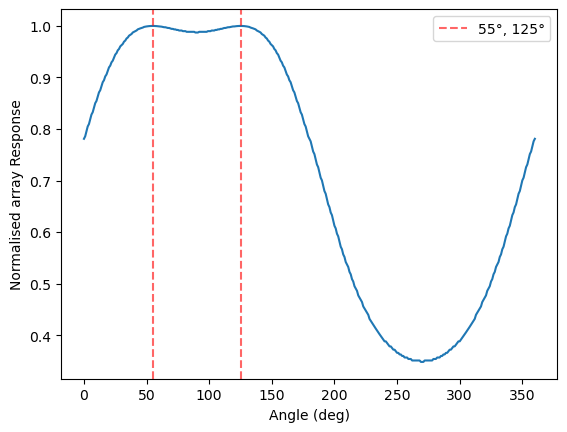

In [53]:
vals = []
for theta0 in np.linspace(0, tmax, tmax+1):
    p2 = 0.5*d*np.sin(theta0*np.pi/180)/c0
    p1 = d*np.sin(theta0*np.pi/180)/c0
    sig2 = shift_signal(sig2a, -p2)
    sig1 = shift_signal(sig1a, -p1)
    sig = sig1 + sig2 + sig3
    q1 = np.sqrt(np.mean(sig1**2))
    q2 = np.sqrt(np.mean(sig2**2))
    q3 = np.sqrt(np.mean(sig3**2))
    qs = np.sqrt(np.mean(sig**2))
    q = qs/(q1 + q2 + q3)
    vals.append(q)
plt.plot(vals)
plt.xlabel('Angle (deg)')
plt.ylabel('Normalised array Response')
plt.axvline(theta, color = 'r', ls = '--', alpha = 0.6, label = f'{theta}°, {180 - theta}°')
plt.axvline(180 - theta, color = 'r', ls = '--', alpha = 0.6)
plt.legend()
# plt.savefig('Array Response vs angles.png')

## 4. Different directions

In [80]:
def wft(f1, f2, a1, a2, theta, title):
    t = 1
    fsample = 110000
    samples = np.linspace(0, t, fsample)
    freq1 = f1
    freq2 = f2
    sig3_1 = a1*np.sin(2*np.pi*freq1*samples)
    sig3_2 = a2*np.sin(2*np.pi*freq2*samples)
    tp = 3*int(fsample / max(freq1, freq2))
    
    sig3 = sig3_1 + sig3_2

    # Array response
    d = 0.3
    c0 = 340
    
    tpi = int((fsample/(t*max(freq1, freq2)))*5)
    tpf = int((fsample/(t*max(freq1, freq2)))*10)
    
    fig, ax = plt.subplots(figsize = (8, 4))
    p2 = 0.5*d*np.sin(theta*np.pi/180)/c0
    p1 = d*np.sin(theta*np.pi/180)/c0
    sig2a = shift_signal(sig3, p2)
    sig1a = shift_signal(sig3, p1)
    sig = sig1a + sig2a + sig3
    ax.plot(samples[tpi:tpf], sig3[tpi:tpf], label = '3', alpha = 0.5, ls = '--')
    ax.plot(samples[tpi:tpf], sig1a[tpi:tpf], label = '1', alpha = 0.5, ls = '--')
    ax.plot(samples[tpi:tpf], sig2a[tpi:tpf], label = '2', alpha = 0.5, ls = '--')
    ax.plot(samples[tpi:tpf], sig[tpi:tpf], label = 'Array', alpha = 0.7, color = 'purple')
    ax.legend()
    ax.set_ylabel("Amplitude")
    ax.set_xlabel("Time (s)")
    # ax.set_ylim([-1.5, 1.5])
    ax.axhline(0, color = 'grey', lw = 0.7)
    ax.set_title(f'Wavefront {title} angle: {theta}deg')
    plt.show(fig)
    plt.close(fig)

    return [sig1a, sig2a, sig3], samples, fig

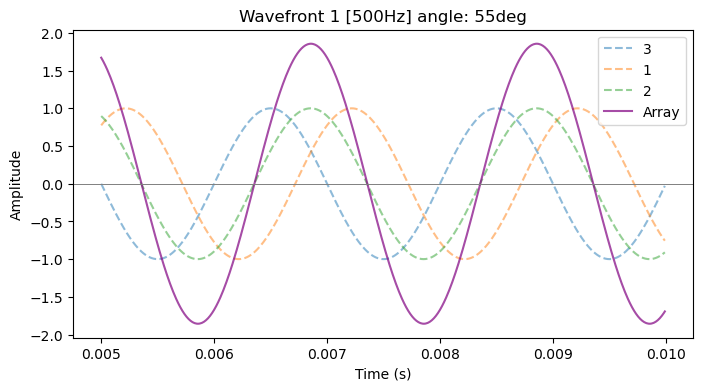

In [84]:
siga1, samples, fig1 = wft(500, 1000, 1, 0, 55, '1 [500Hz]')
fig1.savefig('Signal1_DF.png')

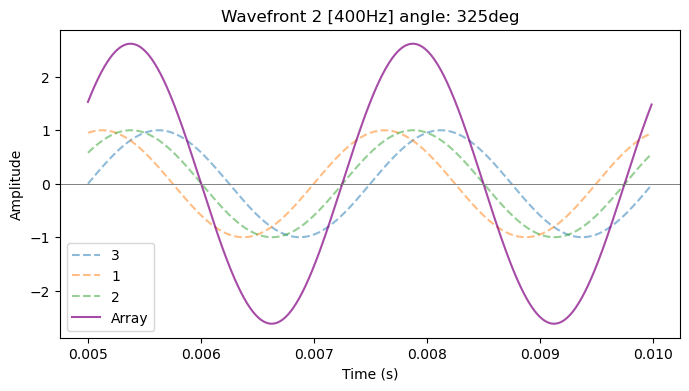

In [86]:
siga2, samples, fig2 = wft(400, 1000, 1, 0, 325, '2 [400Hz]')
fig2.savefig('Signal2_DF.png')

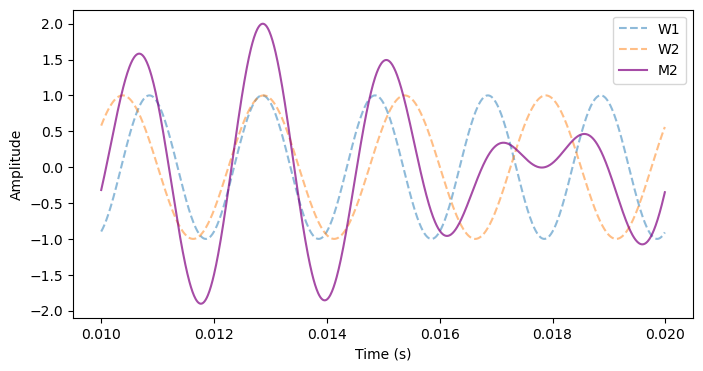

In [98]:
# Mic2
fig, ax = plt.subplots(figsize = (8, 4))
freq1, freq2 = 400, 500
tpi = int((fsample/(t*max(freq1, freq2)))*5)
tpf = int((fsample/(t*max(freq1, freq2)))*10)
sig2a = siga1[1] + siga2[1]
ax.plot(samples[tpi:tpf], siga1[1][tpi:tpf], label = 'W1', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], siga2[1][tpi:tpf], label = 'W2', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], sig2a[tpi:tpf], label = 'M2', alpha = 0.7, color = 'purple')
ax.legend()
ax.set_ylabel("Amplitude")
ax.set_xlabel("Time (s)")
fig.savefig('DF_M2.png')

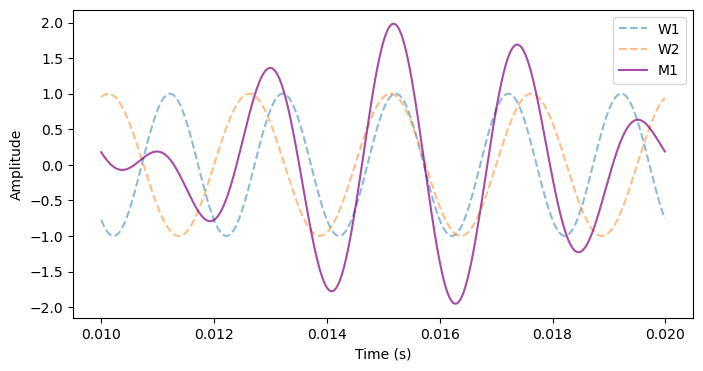

In [100]:
# Mic1
fig, ax = plt.subplots(figsize = (8, 4))
freq1, freq2 = 400, 500
tpi = int((fsample/(t*max(freq1, freq2)))*5)
tpf = int((fsample/(t*max(freq1, freq2)))*10)
sig1a = siga1[0] + siga2[0]
ax.plot(samples[tpi:tpf], siga1[0][tpi:tpf], label = 'W1', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], siga2[0][tpi:tpf], label = 'W2', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], sig1a[tpi:tpf], label = 'M1', alpha = 0.7, color = 'purple')
ax.legend()
ax.set_ylabel("Amplitude")
ax.set_xlabel("Time (s)")
fig.savefig('DF_M1.png')

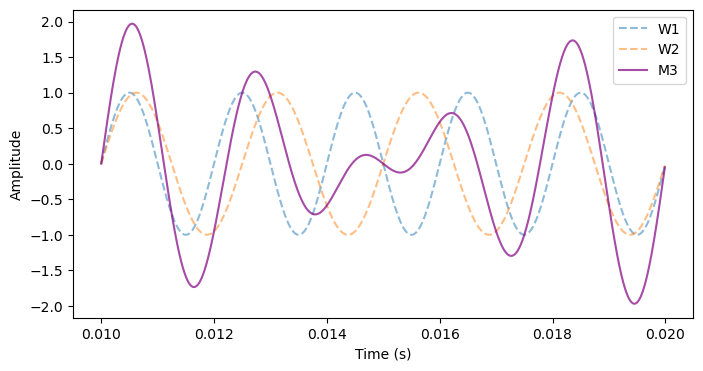

In [102]:
#Mic 3
fig, ax = plt.subplots(figsize = (8, 4))
freq1, freq2 = 400, 500
tpi = int((fsample/(t*max(freq1, freq2)))*5)
tpf = int((fsample/(t*max(freq1, freq2)))*10)
sig3a = siga1[2] + siga2[2]
ax.plot(samples[tpi:tpf], siga1[2][tpi:tpf], label = 'W1', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], siga2[2][tpi:tpf], label = 'W2', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], sig3a[tpi:tpf], label = 'M3', alpha = 0.7, color = 'purple')
ax.legend()
ax.set_ylabel("Amplitude")
ax.set_xlabel("Time (s)")
fig.savefig('DF_M3.png')

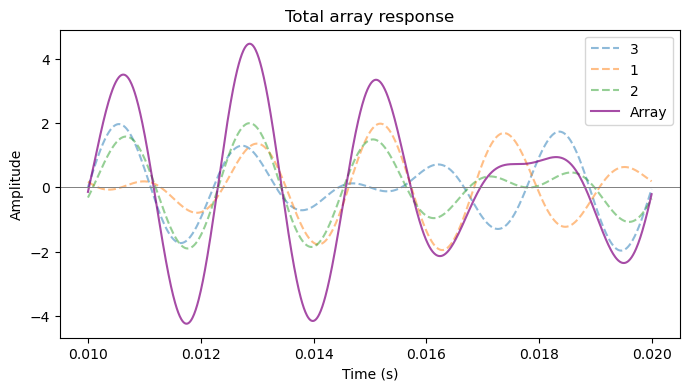

In [106]:
# Total array response
sig3 = siga1[2] + siga2[2]
sig2a = siga1[1] + siga2[1]
sig1a = siga1[0] + siga2[0]
sig = sig1a + sig2a + sig3

freq1, freq2 = 400, 500
tpi = int((fsample/(t*max(freq1, freq2)))*5)
tpf = int((fsample/(t*max(freq1, freq2)))*10)

fig, ax = plt.subplots(figsize = (8, 4))

ax.plot(samples[tpi:tpf], sig3[tpi:tpf], label = '3', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], sig1a[tpi:tpf], label = '1', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], sig2a[tpi:tpf], label = '2', alpha = 0.5, ls = '--')
ax.plot(samples[tpi:tpf], sig[tpi:tpf], label = 'Array', alpha = 0.7, color = 'purple')
ax.legend()
ax.set_ylabel("Amplitude")
ax.set_xlabel("Time (s)")
# ax.set_ylim([-1.5, 1.5])
ax.axhline(0, color = 'grey', lw = 0.7)
ax.set_title(f'Total array response')
fig.savefig('DF_recordings.png')

In [124]:
ang1, ang2 = 55, 325
lim = 2.5
tmax = 360
frames = []
for ang0 in np.linspace(0, tmax, tmax+1):
    r, c = 13, 10
    sq = 6
    fig = plt.figure(figsize=(r, c))
    ax1 = plt.subplot2grid((c, r), (0, int(0.5*(r - sq))), rowspan=sq, colspan=sq)
    ax2 = plt.subplot2grid((c, r), (6, 0), rowspan=4, colspan=r)
    ax1.scatter([-1, 0, 1], [0, 0, 0], color = 'black')
    ax1.plot([1, 1-lim*np.cos(ang1*np.pi/180)], [0, lim*np.sin(ang1*np.pi/180)], color = 'black', ls = '--', alpha = 0.4, label = f'Actual {ang1}°')
    ax1.plot([-1, -1+lim*np.cos(ang2*np.pi/180)], [0, -lim*np.sin(ang2*np.pi/180)], color = 'red', ls = '--', alpha = 0.4, label = f'Actual {ang2}°')
    ax1.plot([1, 1-lim*np.cos(ang0*np.pi/180)], [0, lim*np.sin(ang0*np.pi/180)], alpha = 0.8, ls = '--')
    ax1.set_xlim([-3, 3])
    ax1.set_ylim([-3, 3])
    ax1.legend(bbox_to_anchor = (0, 0.6))
    ax1.set_title(f'Angle = {ang0}°')
    ax1.set_xticks([])
    ax1.set_yticks([])
    for spine in ax1.spines.values():
        spine.set_visible(False)
    
    theta0 = ang0
    p2 = 0.5*d*np.sin(theta0*np.pi/180)/c0
    p1 = d*np.sin(theta0*np.pi/180)/c0
    sig2 = shift_signal(sig2a, -p2)
    sig1 = shift_signal(sig1a, -p1)
    sig = sig1 + sig2 + sig3
    ax2.plot(samples[tpi:tpf], sig3[tpi:tpf], ls = '--', label = '3', alpha = 0.5)
    ax2.plot(samples[tpi:tpf], sig1[tpi:tpf], ls = '--', label = '1', alpha = 0.5)
    ax2.plot(samples[tpi:tpf], sig2[tpi:tpf], ls = '--', label = '2', alpha = 0.5)
    ax2.plot(samples[tpi:tpf], sig[tpi:tpf], color = 'purple', label = 'Array', alpha = 0.8)
    ax2.legend(bbox_to_anchor = (1, 0.7))
    ax2.set_ylabel("Amplitude")
    ax2.set_xlabel("Time (s)")
    ax2.set_ylim([-5, 5])
    # ax.axvline(5/freq + p1, color = 'grey', ls = '--')
    # ax.axvline(5/freq + p2, color = 'grey', ls = '--')
    ax2.axhline(0, color = 'grey', lw = 0.7)
    ax2.set_title(f'{freq}Hz Signal')
    
    fig.canvas.draw()
    rgba_buffer = fig.canvas.buffer_rgba()
    image = np.array(rgba_buffer)
    image_rgb = image[:, :, :3]
    frames.append(image_rgb)
    plt.close(fig)
imageio.mimsave('steering_DF.gif', frames, fps = 20, loop=0)

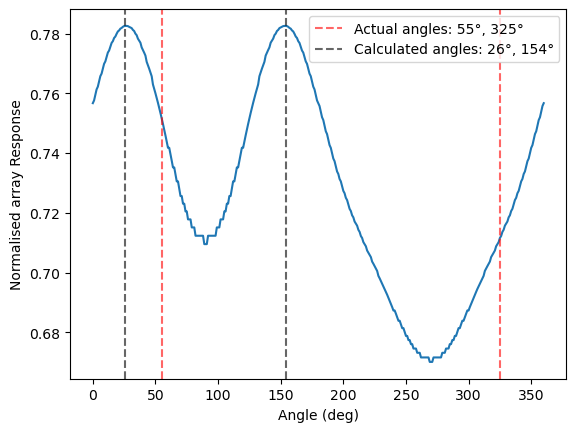

In [144]:
vals = []
for theta0 in np.linspace(0, tmax, tmax+1):
    p2 = 0.5*d*np.sin(theta0*np.pi/180)/c0
    p1 = d*np.sin(theta0*np.pi/180)/c0
    sig2 = shift_signal(sig2a, -p2)
    sig1 = shift_signal(sig1a, -p1)
    sig = sig1 + sig2 + sig3
    q1 = np.sqrt(np.mean(sig1**2))
    q2 = np.sqrt(np.mean(sig2**2))
    q3 = np.sqrt(np.mean(sig3**2))
    qs = np.sqrt(np.mean(sig**2))
    q = qs/(q1 + q2 + q3)
    vals.append(q)
plt.plot(vals)
plt.xlabel('Angle (deg)')
plt.ylabel('Normalised array Response')
plt.axvline(ang1, color = 'r', ls = '--', alpha = 0.6, label = f'Actual angles: {ang1}°, {ang2}°')
plt.axvline(ang2, color = 'r', ls = '--', alpha = 0.6)
angs = [i for i, val in enumerate(vals) if val == max(vals)]
plt.axvline(angs[0], color = 'black', ls = '--', alpha = 0.6, label = f'Calculated angles: {angs[0]}°, {angs[1]}°')
plt.axvline(angs[1], color = 'black', ls = '--', alpha = 0.6)
plt.legend()
# plt.savefig('Array_Response_vs_angles_DF.png')
plt.show()


## 5. Frequency-domain beamforming